# World Cup DDColor Fine-Tuning

The notebook fine-tunes DDColor tiny for World Cup image colorization on a two-GPU CUDA-backed remote Jupyter runtime.

The public DDColorWorldCup repository is cloned inside the session when it is not already available, dependencies are installed inside the notebook, inputs are read from /kaggle/input, and outputs are written under /kaggle/working.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/rubiotelmo/DDColorWorldCup.git"
REPO_ROOT = Path("/kaggle/working/DDColorWorldCup") if Path("/kaggle").exists() else Path.cwd()
if not (REPO_ROOT / "ddcolor").exists():
    REPO_ROOT = Path.cwd() / "DDColorWorldCup"
    if not (REPO_ROOT / "ddcolor").exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_ROOT)], check=True)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
REPO_ROOT

PosixPath('/kaggle/working/DDColorWorldCup')

In [2]:
%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install -q opencv-python-headless scikit-image tqdm huggingface-hub matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 79.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 95.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 33.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.6 MB/s eta 0:00:0000:0100:01
     ━━━━

In [3]:
from pathlib import Path
import os
import random
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import PyTorchModelHubMixin
from skimage import color
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

from basicsr.archs.discriminator_arch import DynamicUNetDiscriminator
from basicsr.losses.losses import ColorfulnessLoss, GANLoss, PerceptualLoss
from basicsr.metrics.colorfulness import calculate_cf
from basicsr.utils.img_util import tensor_lab2rgb
from ddcolor import DDColor

DATA_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working/wcddcolor_runs")
IMG_SIZE = 256
EPOCHS = 5
BATCH_SIZE = 4
LR = 1e-4
SEED = 0

assert torch.cuda.device_count() >= 2, "Two CUDA GPUs are required."
WORLD_SIZE = 2
device = torch.device("cuda:0")
WORK_DIR.mkdir(parents=True, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 01.- Defining the problem

World Cup image colorization is framed as Lab color prediction. The model receives the grayscale lightness channel L, represented as grayscale RGB for DDColor, and predicts the A and B chrominance channels that are recombined with L in CIELAB space.

The World Cup dataset is imported from /kaggle/input and split into training, validation, and testing partitions.

In [4]:
image_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
image_paths = sorted(p for p in DATA_ROOT.rglob("*") if p.suffix.lower() in image_exts)
random.Random(SEED).shuffle(image_paths)

n_test = max(1, int(0.1 * len(image_paths)))
n_val = max(1, int(0.1 * len(image_paths)))
test_paths = image_paths[:n_test]
val_paths = image_paths[n_test:n_test + n_val]
train_paths = image_paths[n_test + n_val:]

assert train_paths and val_paths and test_paths, "At least three images are required."
len(train_paths), len(val_paths), len(test_paths)

(122083, 15260, 15260)

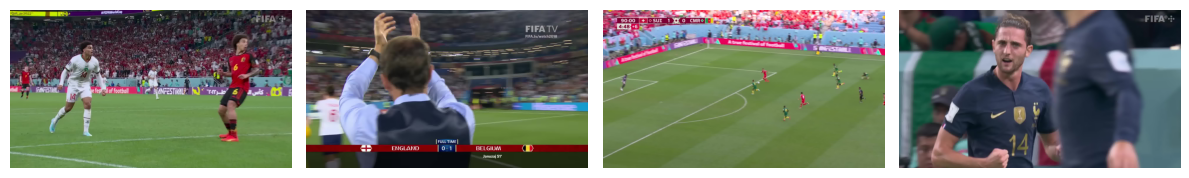

In [5]:
sample_paths = train_paths[:4]
fig, axes = plt.subplots(1, len(sample_paths), figsize=(3 * len(sample_paths), 3))
if len(sample_paths) == 1:
    axes = [axes]
for ax, path in zip(axes, sample_paths):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 02.- Choose a measure of success

The training objective follows the DDColor work with AB L1 reconstruction, VGG perceptual similarity, adversarial realism, and colorfulness regularization.

## 03.- Deciding on an evaluation protocol

The evaluation protocol uses PSNR, SSIM, and predicted-image colorfulness on validation and test images, so model selection does not depend on training loss.

## 04.- Preparing the data

Images are resized, randomly flipped during training, decolored through the Lab lightness channel, and separated into L and AB tensors following the DDColor data flow.

In [6]:
class WorldCupLabDataset(Dataset):
    def __init__(self, paths, train=False):
        self.paths = paths
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        if self.train and random.random() < 0.5:
            img = np.ascontiguousarray(img[:, ::-1])
        lab = color.rgb2lab(img.astype(np.float32) / 255.0).astype(np.float32)
        l = torch.from_numpy(lab[:, :, :1].transpose(2, 0, 1))
        ab = torch.from_numpy(lab[:, :, 1:].transpose(2, 0, 1))
        return l, ab


train_loader = DataLoader(WorldCupLabDataset(train_paths, True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_eval_paths = train_paths[:1024]
val_eval_paths = val_paths[:2048]
train_eval_loader = DataLoader(WorldCupLabDataset(train_eval_paths), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader = DataLoader(WorldCupLabDataset(val_eval_paths), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(WorldCupLabDataset(test_paths), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [7]:
def l_to_rgb(l):
    return tensor_lab2rgb(torch.cat([l, torch.zeros_like(l), torch.zeros_like(l)], dim=1))


def lab_to_rgb(l, ab):
    return tensor_lab2rgb(torch.cat([l, ab], dim=1))


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    psnr, ssim, cf = [], [], []
    for l, ab in loader:
        l, ab = l.to(device), ab.to(device)
        pred_ab = model(l_to_rgb(l))
        pred_rgb = lab_to_rgb(l, pred_ab).cpu().clamp(0, 1)
        gt_rgb = lab_to_rgb(l, ab).cpu().clamp(0, 1)
        for pred, gt in zip(pred_rgb, gt_rgb):
            pred = pred.permute(1, 2, 0).numpy()
            gt = gt.permute(1, 2, 0).numpy()
            psnr.append(peak_signal_noise_ratio(gt, pred, data_range=1.0))
            ssim.append(structural_similarity(gt, pred, channel_axis=2, data_range=1.0))
            cf.append(calculate_cf((pred[:, :, ::-1] * 255).round().astype(np.uint8)))
    return {"psnr": float(np.mean(psnr)), "ssim": float(np.mean(ssim)), "colorfulness": float(np.mean(cf))}

## 05.- Fine tune the DDColor tiny model

The DDColor tiny checkpoint is loaded from Hugging Face. Fine-tuning is launched with torchrun and DistributedDataParallel: two Python processes are started, one per GPU, each process trains on a dataset shard through DistributedSampler, gradients are synchronized by NCCL after backward passes, and only rank 0 saves checkpoints and evaluates metric subsets.

In [8]:
class DDColorHF(DDColor, PyTorchModelHubMixin):
    def __init__(self, config=None, **kwargs):
        if isinstance(config, dict):
            kwargs = {**config, **kwargs}
        super().__init__(**kwargs)


train_script = r'''
import os
import random
import sys
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.distributed as dist
from huggingface_hub import PyTorchModelHubMixin
from skimage import color
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd()))

from basicsr.archs.discriminator_arch import DynamicUNetDiscriminator
from basicsr.losses.losses import ColorfulnessLoss, GANLoss, PerceptualLoss
from basicsr.metrics.colorfulness import calculate_cf
from basicsr.utils.img_util import tensor_lab2rgb
from ddcolor import DDColor

DATA_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working/wcddcolor_runs')
IMG_SIZE = int(os.environ['IMG_SIZE'])
EPOCHS = int(os.environ['EPOCHS'])
BATCH_SIZE = int(os.environ['BATCH_SIZE'])
LR = float(os.environ['LR'])
SEED = int(os.environ['SEED'])


class DDColorHF(DDColor, PyTorchModelHubMixin):
    def __init__(self, config=None, **kwargs):
        if isinstance(config, dict):
            kwargs = {**config, **kwargs}
        super().__init__(**kwargs)


class WorldCupLabDataset(Dataset):
    def __init__(self, paths, train=False):
        self.paths = paths
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        if self.train and random.random() < 0.5:
            img = np.ascontiguousarray(img[:, ::-1])
        lab = color.rgb2lab(img.astype(np.float32) / 255.0).astype(np.float32)
        l = torch.from_numpy(lab[:, :, :1].transpose(2, 0, 1))
        ab = torch.from_numpy(lab[:, :, 1:].transpose(2, 0, 1))
        return l, ab


def l_to_rgb(l):
    return tensor_lab2rgb(torch.cat([l, torch.zeros_like(l), torch.zeros_like(l)], dim=1))


def lab_to_rgb(l, ab):
    return tensor_lab2rgb(torch.cat([l, ab], dim=1))


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    psnr, ssim, cf = [], [], []
    for l, ab in loader:
        l, ab = l.to(device), ab.to(device)
        pred_ab = model(l_to_rgb(l))
        pred_rgb = lab_to_rgb(l, pred_ab).cpu().clamp(0, 1)
        gt_rgb = lab_to_rgb(l, ab).cpu().clamp(0, 1)
        for pred, gt in zip(pred_rgb, gt_rgb):
            pred = pred.permute(1, 2, 0).numpy()
            gt = gt.permute(1, 2, 0).numpy()
            psnr.append(peak_signal_noise_ratio(gt, pred, data_range=1.0))
            ssim.append(structural_similarity(gt, pred, channel_axis=2, data_range=1.0))
            cf.append(calculate_cf((pred[:, :, ::-1] * 255).round().astype(np.uint8)))
    return {'psnr': float(np.mean(psnr)), 'ssim': float(np.mean(ssim)), 'colorfulness': float(np.mean(cf))}


def split_paths():
    image_exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
    image_paths = sorted(p for p in DATA_ROOT.rglob('*') if p.suffix.lower() in image_exts)
    random.Random(SEED).shuffle(image_paths)
    n_test = max(1, int(0.1 * len(image_paths)))
    n_val = max(1, int(0.1 * len(image_paths)))
    return image_paths[n_test + n_val:], image_paths[n_test:n_test + n_val]


def main():
    local_rank = int(os.environ['LOCAL_RANK'])
    rank = int(os.environ['RANK'])
    world_size = int(os.environ['WORLD_SIZE'])
    torch.cuda.set_device(local_rank)
    device = torch.device(f'cuda:{local_rank}')
    dist.init_process_group(backend='nccl')
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if rank == 0:
        WORK_DIR.mkdir(parents=True, exist_ok=True)
    train_paths, val_paths = split_paths()
    train_dataset = WorldCupLabDataset(train_paths, True)
    train_sampler = DistributedSampler(train_dataset, num_replicas=world_size, rank=rank, shuffle=True, seed=SEED)
    per_gpu_batch_size = max(1, BATCH_SIZE // world_size)
    train_loader = DataLoader(train_dataset, batch_size=per_gpu_batch_size, sampler=train_sampler, num_workers=2, pin_memory=True)
    if rank == 0:
        train_eval_paths = train_paths[:1024]
        val_eval_paths = val_paths[:2048]
        train_eval_loader = DataLoader(WorldCupLabDataset(train_eval_paths), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        val_loader = DataLoader(WorldCupLabDataset(val_eval_paths), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    base_model = DDColorHF.from_pretrained('piddnad/ddcolor_paper_tiny').to(device)
    for p in base_model.encoder.parameters():
        p.requires_grad = False
    model = DDP(base_model, device_ids=[local_rank], output_device=local_rank)
    disc = DDP(DynamicUNetDiscriminator(n_channels=3, nf=64).to(device), device_ids=[local_rank], output_device=local_rank)

    pixel_loss = torch.nn.L1Loss()
    perceptual_loss = PerceptualLoss(
        layer_weights={'conv1_1': 0.0625, 'conv2_1': 0.125, 'conv3_1': 0.25, 'conv4_1': 0.5, 'conv5_1': 1.0},
        vgg_type='vgg16_bn', use_input_norm=True, range_norm=False, perceptual_weight=5.0, style_weight=0, criterion='l1'
    ).to(device)
    gan_loss = GANLoss('vanilla', loss_weight=1.0).to(device)
    color_loss = ColorfulnessLoss(loss_weight=0.5).to(device)
    opt_g = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=LR, weight_decay=0.01, betas=(0.9, 0.99))
    opt_d = torch.optim.Adam(disc.parameters(), lr=LR, betas=(0.9, 0.99))

    start_epoch = 0
    best_ssim = -1.0
    history = []
    checkpoint_path = WORK_DIR / 'checkpoint.pt'
    best_path = WORK_DIR / 'best_ddcolor_tiny_worldcup.pt'
    if checkpoint_path.exists():
        state = torch.load(checkpoint_path, map_location=device)
        model.module.load_state_dict(state['model'])
        disc.module.load_state_dict(state['discriminator'])
        opt_g.load_state_dict(state['opt_g'])
        opt_d.load_state_dict(state['opt_d'])
        start_epoch = state['epoch'] + 1
        best_ssim = state['best_ssim']
        history = state.get('history', [])

    for epoch in range(start_epoch, EPOCHS):
        train_sampler.set_epoch(epoch)
        model.train()
        model.module.encoder.eval()
        disc.train()
        running_g, running_d = 0.0, 0.0
        iterator = train_loader if rank else tqdm(train_loader, desc=f'epoch {epoch + 1}/{EPOCHS}')
        for l, ab in iterator:
            l, ab = l.to(device), ab.to(device)
            gray_rgb = l_to_rgb(l)
            gt_rgb = lab_to_rgb(l, ab)

            for p in disc.parameters():
                p.requires_grad_(False)
            opt_g.zero_grad(set_to_none=True)
            pred_ab = model(gray_rgb)
            pred_rgb = lab_to_rgb(l, pred_ab)
            loss_perc, _ = perceptual_loss(pred_rgb, gt_rgb)
            loss_g = 0.1 * pixel_loss(pred_ab, ab) + loss_perc + gan_loss(disc.module(pred_rgb), True, is_disc=False) + color_loss(pred_rgb)
            loss_g.backward()
            opt_g.step()

            for p in disc.parameters():
                p.requires_grad_(True)
            opt_d.zero_grad(set_to_none=True)
            loss_d = gan_loss(disc(gt_rgb), True, is_disc=True) + gan_loss(disc(pred_rgb.detach()), False, is_disc=True)
            loss_d.backward()
            opt_d.step()
            running_g += loss_g.item()
            running_d += loss_d.item()

        totals = torch.tensor([running_g, running_d, len(train_loader)], device=device)
        dist.all_reduce(totals, op=dist.ReduceOp.SUM)
        dist.barrier()
        if rank == 0:
            train_metrics = evaluate(model.module, train_eval_loader, device)
            val_metrics = evaluate(model.module, val_loader, device)
            epoch_history = {
                'epoch': epoch + 1,
                'g_loss': (totals[0] / totals[2]).item(),
                'd_loss': (totals[1] / totals[2]).item(),
                **{f'train_{k}': v for k, v in train_metrics.items()},
                **{f'val_{k}': v for k, v in val_metrics.items()},
            }
            history.append(epoch_history)
            if val_metrics['ssim'] > best_ssim:
                best_ssim = val_metrics['ssim']
                torch.save({'model': model.module.state_dict(), 'epoch': epoch, 'metrics': val_metrics}, best_path)
            torch.save({
                'model': model.module.state_dict(), 'discriminator': disc.module.state_dict(),
                'opt_g': opt_g.state_dict(), 'opt_d': opt_d.state_dict(), 'epoch': epoch,
                'best_ssim': best_ssim, 'metrics': val_metrics, 'history': history,
            }, checkpoint_path)
            print(epoch_history)
        dist.barrier()
    dist.destroy_process_group()


if __name__ == '__main__':
    main()
'''

(WORK_DIR / 'ddp_train_worldcup.py').write_text(train_script)

8932

In [9]:
env = os.environ.copy()
env.update({"IMG_SIZE": str(IMG_SIZE), "EPOCHS": str(EPOCHS), "BATCH_SIZE": str(BATCH_SIZE), "LR": str(LR), "SEED": str(SEED)})
subprocess.run([
    "torchrun", "--standalone", "--nproc_per_node", str(WORLD_SIZE), str(WORK_DIR / "ddp_train_worldcup.py")
], check=True, env=env)

checkpoint_path = WORK_DIR / "checkpoint.pt"
best_path = WORK_DIR / "best_ddcolor_tiny_worldcup.pt"
history = torch.load(checkpoint_path, map_location="cpu").get("history", [])

W0531 06:56:22.569000 155 torch/distributed/run.py:793] 
W0531 06:56:22.569000 155 torch/distributed/run.py:793] *****************************************
W0531 06:56:22.569000 155 torch/distributed/run.py:793] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0531 06:56:22.569000 155 torch/distributed/run.py:793] *****************************************
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/t

{'epoch': 3, 'g_loss': 3.1192855834960938, 'd_loss': 1.230259895324707, 'train_psnr': 23.189309006540086, 'train_ssim': 0.902489423751831, 'train_colorfulness': 47.5827095651088, 'val_psnr': 23.287262770393177, 'val_ssim': 0.9045509099960327, 'val_colorfulness': 47.60159985000823}


epoch 4/5: 100%|██████████| 30521/30521 [2:57:28<00:00,  2.87it/s]  


{'epoch': 4, 'g_loss': 3.184950351715088, 'd_loss': 1.1754157543182373, 'train_psnr': 23.271778180205203, 'train_ssim': 0.9014727473258972, 'train_colorfulness': 48.870966884124414, 'val_psnr': 23.36412626623272, 'val_ssim': 0.9034135341644287, 'val_colorfulness': 48.976885574932936}


epoch 5/5: 100%|██████████| 30521/30521 [2:57:33<00:00,  2.86it/s]  


{'epoch': 5, 'g_loss': 3.2502200603485107, 'd_loss': 1.1276224851608276, 'train_psnr': 23.267965102602247, 'train_ssim': 0.9047035574913025, 'train_colorfulness': 47.86803039157074, 'val_psnr': 23.29554544525175, 'val_ssim': 0.9061256051063538, 'val_colorfulness': 47.92282469742159}


/tmp/ipykernel_102/1965549724.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  history = torch.load(checkpoint_path, map_location="cpu").get("history", [])


Learning curves compare training and validation metrics across epochs so overfitting can be inspected after fine-tuning.

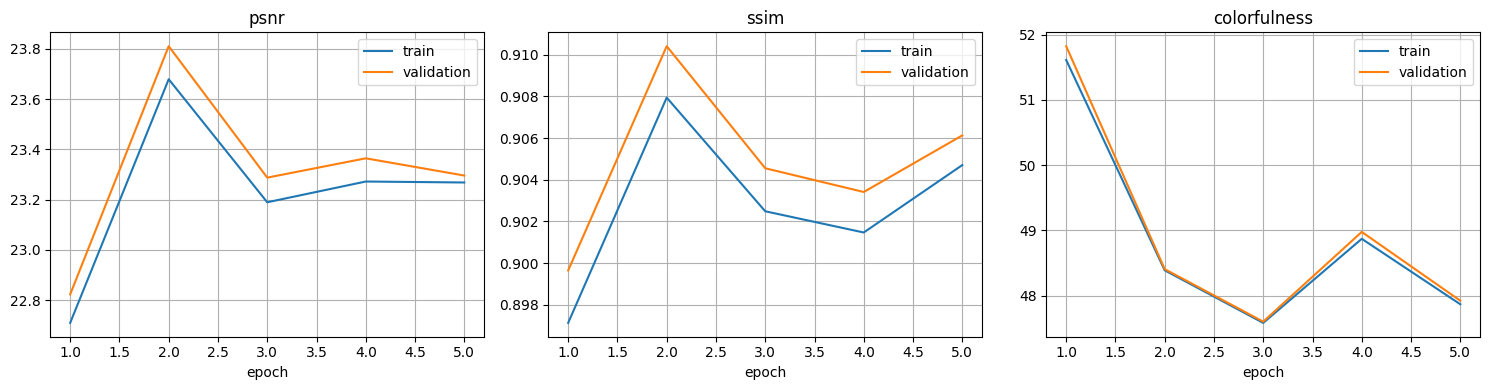

In [10]:
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["psnr", "ssim", "colorfulness"]):
    ax.plot(epochs, [row[f"train_{metric}"] for row in history], label="train")
    ax.plot(epochs, [row[f"val_{metric}"] for row in history], label="validation")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.grid(True)
    ax.legend()
fig.tight_layout()
fig.savefig(WORK_DIR / "learning_curves.png", dpi=150)
plt.show()

## 06.- Final model testing

The best validation checkpoint is evaluated on the held-out test partition, and a compact visual grid records grayscale inputs, predictions, and ground truth images.

In [11]:
model = DDColorHF.from_pretrained("piddnad/ddcolor_paper_tiny").to(device)
best = torch.load(best_path, map_location=device)
model.load_state_dict(best["model"])
test_metrics = evaluate(model, test_loader)
print(test_metrics)

l, ab = next(iter(test_loader))
l, ab = l[:4].to(device), ab[:4].to(device)
model.eval()
with torch.no_grad():
    gray_rgb = l_to_rgb(l).cpu().clamp(0, 1)
    pred_rgb = lab_to_rgb(l, model(l_to_rgb(l))).cpu().clamp(0, 1)
    gt_rgb = lab_to_rgb(l, ab).cpu().clamp(0, 1)

grid = make_grid(torch.cat([gray_rgb, pred_rgb, gt_rgb], dim=0), nrow=l.size(0))
save_image(grid, WORK_DIR / "test_examples.png")

/tmp/ipykernel_102/1554355289.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(best_path, map_location=device)


{'psnr': 23.808010700812158, 'ssim': 0.9102439284324646, 'colorfulness': 48.42914468526085}


/tmp/ipykernel_102/499653349.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(best_path, map_location=device)


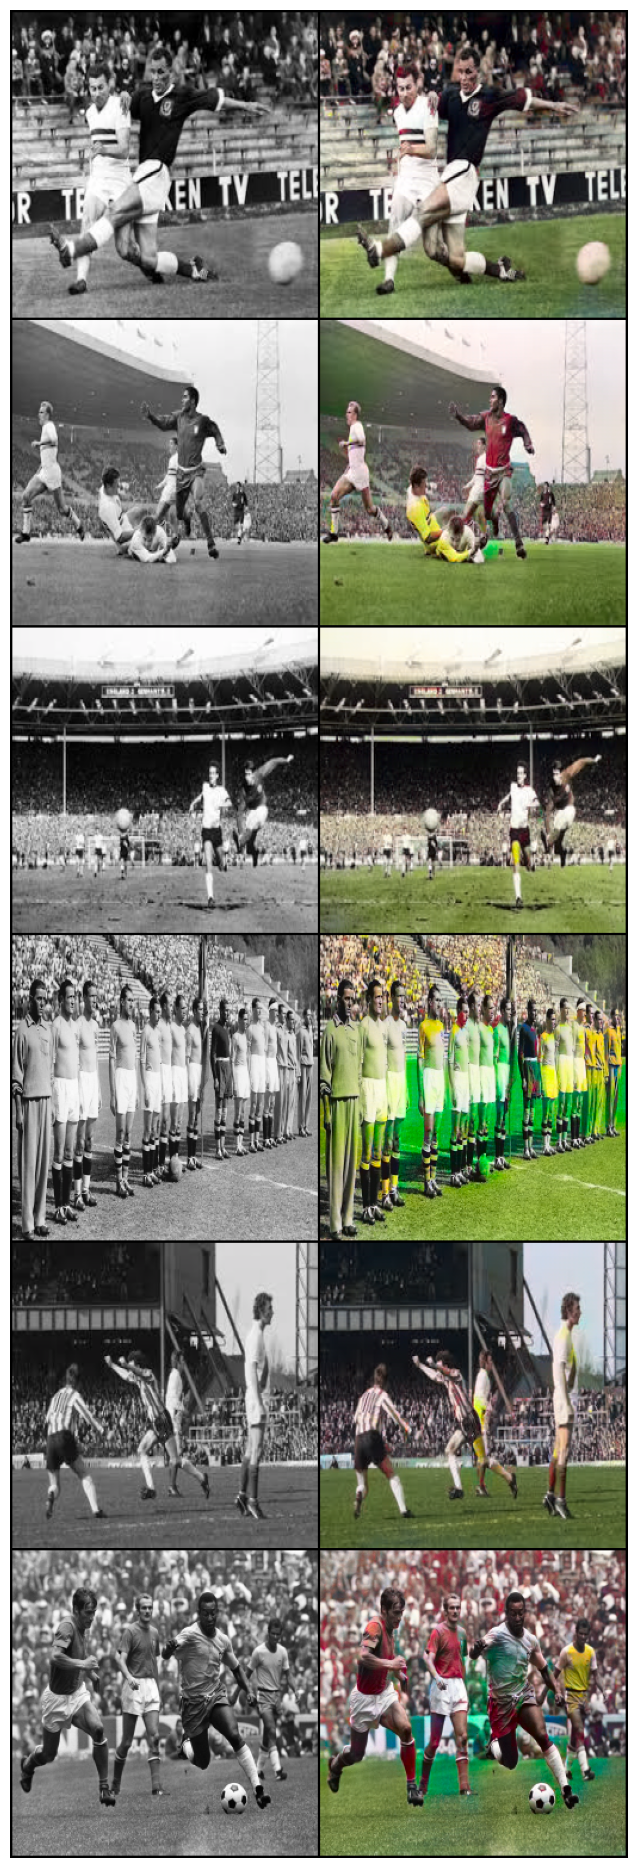

In [13]:
TEST_DIR = Path("/kaggle/input/datasets/telmorubio/wc-coloring-testing/test_images/")
PRED_DIR = WORK_DIR / "test_image_predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

model = DDColorHF.from_pretrained("piddnad/ddcolor_paper_tiny").to(device)
best = torch.load(best_path, map_location=device)
model.load_state_dict(best["model"])
model.eval()

image_paths = sorted(p for p in TEST_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"})
assert image_paths, f"No images found in {TEST_DIR}"

rows = []
with torch.no_grad():
    for path in image_paths:
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        lab = color.rgb2lab(img.astype(np.float32) / 255.0).astype(np.float32)

        l = torch.from_numpy(lab[:, :, :1].transpose(2, 0, 1)).unsqueeze(0).to(device)
        pred_ab = model(l_to_rgb(l))
        pred_rgb = lab_to_rgb(l, pred_ab).cpu().clamp(0, 1)[0]

        gray_rgb = l_to_rgb(l).cpu().clamp(0, 1)[0]
        pred_img = (pred_rgb.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
        cv2.imwrite(str(PRED_DIR / path.name), cv2.cvtColor(pred_img, cv2.COLOR_RGB2BGR))

        rows.extend([gray_rgb, pred_rgb])

grid = make_grid(rows, nrow=2)
save_image(grid, WORK_DIR / "test_image_predictions_grid.png")
plt.figure(figsize=(10, 4 * len(image_paths)))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()